In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [2]:
def make_df(file_path):
    df = pd.DataFrame()

    tritrig_file = uproot.open(file_path)

    # Open ROOT tree
    tree = tritrig_file['preselection']

    # Access branches
    B_vertex = tree['vertex.']
    B_ele = tree['ele.']
    B_pos = tree['pos.']


    # Get vertex positions
    vertex_pos = B_vertex['vertex.pos_'].array()
    df['vertex_pos_x'] = np.array(vertex_pos['fX'])
    df['vertex_pos_y'] = np.array(vertex_pos['fY'])
    df['vertex_pos_z'] = np.array(vertex_pos['fZ'])

    # Get arrays of the electron and positron energies as measured with Ecal
    df['ele_E_Ecal'] = np.array(B_ele['ele.energy_'])
    df['pos_E_Ecal'] = np.array(B_pos['pos.energy_'])
    # Get number of hits in Ecal clusters

    # Get Ecal cluster positions
    df['ele_Ecal_x']= np.array(B_ele['ele.cluster_.x_'])
    df['ele_Ecal_y']= np.array(B_ele['ele.cluster_.y_'])
    df['ele_Ecal_z']= np.array(B_ele['ele.cluster_.z_'])
    df['pos_Ecal_x']= np.array(B_pos['pos.cluster_.x_'])
    df['pos_Ecal_y']= np.array(B_pos['pos.cluster_.y_'])
    df['pos_Ecal_z']= np.array(B_pos['pos.cluster_.z_'])

    # Get number of hits on track
    df['ele_trk_nhits'] = np.array(B_ele[ 'ele.track_/ele.track_.n_hits_'])
    df['pos_trk_nhits'] = np.array(B_pos[ 'pos.track_/pos.track_.n_hits_'])
    # Get Electron and Positron momenta
    arr = B_vertex['vertex.p1_'].array()
    df['ele_Px'] = np.array(arr['fX'])
    df['ele_Py'] = np.array(arr['fY'])
    df['ele_Pz'] = np.array(arr['fZ'])
    arr = B_vertex['vertex.p2_'].array()
    df['pos_Px'] = np.array(arr['fX'])
    df['pos_Py'] = np.array(arr['fY'])
    df['pos_Pz'] = np.array(arr['fZ'])
    # Collect track parameters for electrons and positrons
    df['ele_phi0'] = -np.array(B_ele['ele.track_/ele.track_.phi0_'])
    df['ele_dp'] = np.array(B_ele['ele.track_/ele.track_.d0_'])
    df['ele_kappa_o_alpha'] = -np.array(B_ele['ele.track_/ele.track_.omega_'])
    df['ele_dz'] = -np.array(B_ele['ele.track_/ele.track_.z0_'])
    df['ele_tan_lambda'] = -np.array(B_ele['ele.track_/ele.track_.tan_lambda_'])
    df['pos_phi0'] = -np.array(B_pos['pos.track_/pos.track_.phi0_'])
    df['pos_dp'] = np.array(B_pos['pos.track_/pos.track_.d0_'])
    df['pos_kappa_o_alpha'] = -np.array(B_pos['pos.track_/pos.track_.omega_'])
    df['pos_dz'] = -np.array(B_pos['pos.track_/pos.track_.z0_'])
    df['pos_tan_lambda'] = -np.array(B_pos['pos.track_/pos.track_.tan_lambda_'])

    df['e_Pz'] = np.array(B_ele['ele.pz_'])
    df['e_Px'] = np.array(B_ele['ele.px_'])
    df['e_Py'] = np.array(B_ele['ele.py_'])
    df['p_Pz'] = np.array(B_pos['pos.pz_'])
    df['p_Px'] = np.array(B_pos['pos.px_'])
    df['p_Py'] = np.array(B_pos['pos.py_'])

    df['ele_P'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    df['pos_P'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)

    df['e_P'] = np.sqrt(df['e_Px']**2 + df['e_Py']**2 + df['e_Pz']**2)
    df['p_P'] = np.sqrt(df['p_Px']**2 + df['p_Py']**2 + df['p_Pz']**2)

    df['vertex_Ptot'] = df['ele_P'] + df['pos_P']
    df['Ptot'] = df['e_P'] + df['p_P']
    df['Psum'] = np.array(tree['psum'])

    return df


In [6]:
# Create dataframes 
#df_tritrig_2019= make_df('/Users/mghrear/data/HPS_mc/2019_tritrig_pulser_recon_2_pt2/tritrig.root')
#df_data_2019 = make_df('/Users/mghrear/data/HPS_data/2019_flattened2/2019_run010051.root')
#df_data_2019 = make_df('/Users/mghrear/data/HPS_data/2019_run010051_large/2019_010051_large.root')

df_tritrig_2021 = make_df('/Users/mghrear/data/HPS_mc/2021_v9_pass5/tritrig/tritrig_pulser_smeared_hadd_500files.root')
df_data_2021_v9 = make_df('/Users/mghrear/Desktop/merged_hps_014191_job2.root')
#df_data_2021_old = make_df('/Users/mghrear/data/HPS_data/WithChargesData/merged.root')



# 2019 Data

Text(0.5, 0, 'Psum (GeV)')

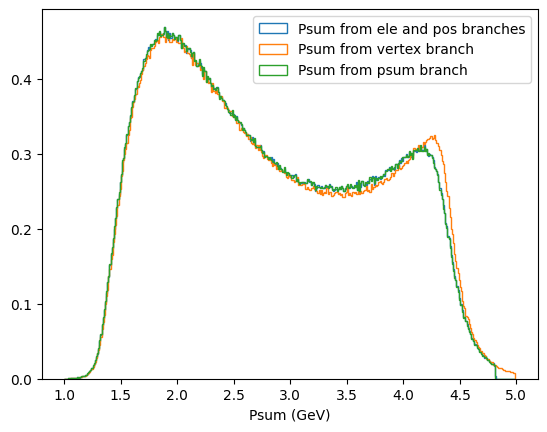

In [8]:
plt.hist(df_data_2019['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_data_2019['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_data_2019['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
#plt.hist(df_data_2019['Psum']*0.81374, bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')

plt.legend()
plt.xlabel('Psum (GeV)')


In [9]:
df_data_2019['Ptot']/df_data_2019['Psum']

0          1.000263
1          1.000266
2          1.001571
3          1.000862
4          1.000227
             ...   
3341063    1.000148
3341064    1.001116
3341065    1.000596
3341066    1.001454
3341067    1.000579
Length: 3341068, dtype: float64

# 2019 MC

In [10]:
plt.hist(df_tritrig_2019['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_tritrig_2019['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_tritrig_2019['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
plt.legend()
plt.xlabel('Psum (GeV)')

NameError: name 'df_tritrig_2019' is not defined

In [11]:
df_tritrig_2019['Ptot']/df_tritrig_2019['Psum']

NameError: name 'df_tritrig_2019' is not defined

# 2021 Data

Text(0.5, 0, 'Psum (GeV)')

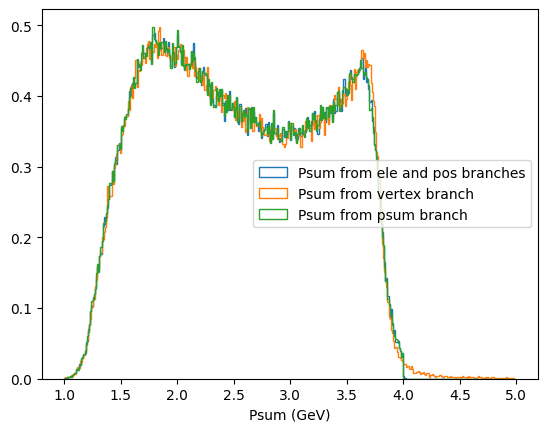

In [7]:
plt.hist(df_data_2021_v9['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_data_2021_v9['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_data_2021_v9['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
plt.legend()
plt.xlabel('Psum (GeV)')


In [8]:
df_data_2021_v9['Ptot']/df_data_2021_v9['Psum']

0         1.000321
1         1.000206
2         1.001102
3         1.000313
4         1.000664
            ...   
354162    1.001925
354163    1.001474
354164    1.000499
354165    1.000244
354166    1.000789
Length: 354167, dtype: float64

# 2021 MC


Text(0.5, 0, 'Psum (GeV)')

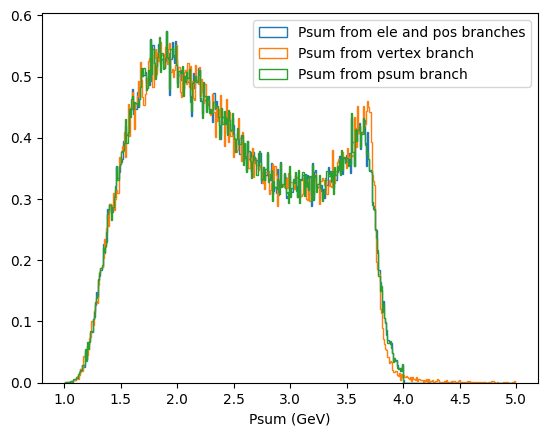

In [9]:
plt.hist(df_tritrig_2021['Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from ele and pos branches')
plt.hist(df_tritrig_2021['vertex_Ptot'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from vertex branch')
plt.hist(df_tritrig_2021['Psum'], bins=np.arange(1,5.0,0.01), histtype='step', density=True, label = 'Psum from psum branch')
plt.legend()
plt.xlabel('Psum (GeV)')

In [10]:
df_tritrig_2021['Ptot']/df_tritrig_2021['Psum']

0         1.000454
1         1.000667
2         1.000871
3         1.000451
4         1.000275
            ...   
120734    1.000588
120735    1.000982
120736    1.000398
120737    1.000465
120738    1.000248
Length: 120739, dtype: float64